# Fundamental Analysis
- 분석할 대상: IT(wics code: 45)
- 사용할 데이터
    - 글로벌 경제 분석 데이터: ./data/analysis/asset*.csv
    - IT 데이터: ./data/wics/*

## 0. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 경로 설정
BASE_ASSET   = os.path.join('data', 'analysis')
BASE_WICS    = os.path.join('data', 'wics')
OUT_DIR      = os.path.join('data', 'analysis/it')
os.makedirs(OUT_DIR, exist_ok=True)

IT_CODE = 'G45'   # WICS IT 섹터 코드 prefix

print('✅ 라이브러리 로딩 완료')

✅ 라이브러리 로딩 완료


## 2단계: IT와 글로벌 경제 요소들의 상관관계 분석 
- 어떤 요소들이 년도별 IT 산업 라이프사이클, 시장 규모, 성장 잠재력에 영향을 끼치는지 분석 

### 1. 글로벌 경제 통합 데이터 로딩 (asset_combined_close.csv)

In [2]:
# 1. 글로벌 자산 Close 데이터 로딩
close_path = os.path.join(BASE_ASSET, 'asset_combined_close.csv')
df_asset = pd.read_csv(close_path, encoding='utf-8-sig', index_col='Date', parse_dates=True)
df_asset = df_asset.sort_index()

print(f'글로벌 자산 데이터: {df_asset.shape}')
print(f'날짜 범위: {df_asset.index[0].date()} ~ {df_asset.index[-1].date()}')
print(f'컬럼: {list(df_asset.columns)}')
df_asset.tail(3)

글로벌 자산 데이터: (1280, 8)
날짜 범위: 2021-03-29 ~ 2026-03-27
컬럼: ['구리(HG=F)', '금(GC=F)', '반도체(SOX)', '석유(WTI)', '해운운임(BDI)', '미국10년국채(TNX)', '미국CPI_CPIAUCSL', '미국CPI_YoY']


,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX),미국CPI_CPIAUCSL,미국CPI_YoY
Date,,,,,,,,
2026-03-25,5.5290,4549.799805,7967.750000,90.320000,10.00,4.328,NaN,NaN
2026-03-26,5.4465,4375.500000,7585.870117,94.480003,10.00,4.416,NaN,NaN
2026-03-27,5.4670,4492.000000,7457.669922,99.639999,9.93,4.440,NaN,NaN


### 2. IT 섹터 WICS 데이터 로딩 (2021~2026)

In [3]:
def load_wics_year(year):
    """연도별 WICS 데이터 로딩 (zip 또는 csv 자동 처리)"""
    zip_path = os.path.join(BASE_WICS, f'wics_company_{year}.zip')
    csv_path = os.path.join(BASE_WICS, f'wics_company_{year}.csv')

    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path) as z:
            with z.open(z.namelist()[0]) as f:
                df = pd.read_csv(f, encoding='utf-8-sig')
    elif os.path.exists(csv_path):
        df = pd.read_csv(csv_path, encoding='utf-8-sig')
    else:
        return None

    df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
    return df


# 전체 연도 로딩 & IT 필터링
years = [2021, 2022, 2023, 2024, 2025, 2026]
wics_frames = []
for y in years:
    df_y = load_wics_year(y)
    if df_y is not None:
        it_mask = df_y['IDX_CD'].str.startswith(IT_CODE)
        wics_frames.append(df_y[it_mask])
        print(f'{y}: IT 행 {it_mask.sum():,}')

df_wics = pd.concat(wics_frames, ignore_index=True)
print(f'\n통합 IT WICS 데이터: {df_wics.shape}')
print(f'날짜 범위: {df_wics["DATE"].min().date()} ~ {df_wics["DATE"].max().date()}')
df_wics[['IDX_CD','IDX_NM_KOR','CMP_CD','CMP_KOR','MKT_VAL','DATE']].head(3)

2021: IT 행 140,863
2022: IT 행 148,290
2023: IT 행 158,994
2024: IT 행 164,672
2025: IT 행 168,007
2026: IT 행 40,054

통합 IT WICS 데이터: (820880, 30)
날짜 범위: 2021-01-04 ~ 2026-03-27


,IDX_CD,IDX_NM_KOR,CMP_CD,CMP_KOR,MKT_VAL,DATE
0,G4510,WICS 소프트웨어와서비스,18260,삼성에스디에스,6188676,2021-01-04
1,G4510,WICS 소프트웨어와서비스,12510,더존비즈온,1914740,2021-01-04
2,G4510,WICS 소프트웨어와서비스,60250,NHN KCP,977660,2021-01-04


### 3. IT 업종 시가총액 시계열 (월별)

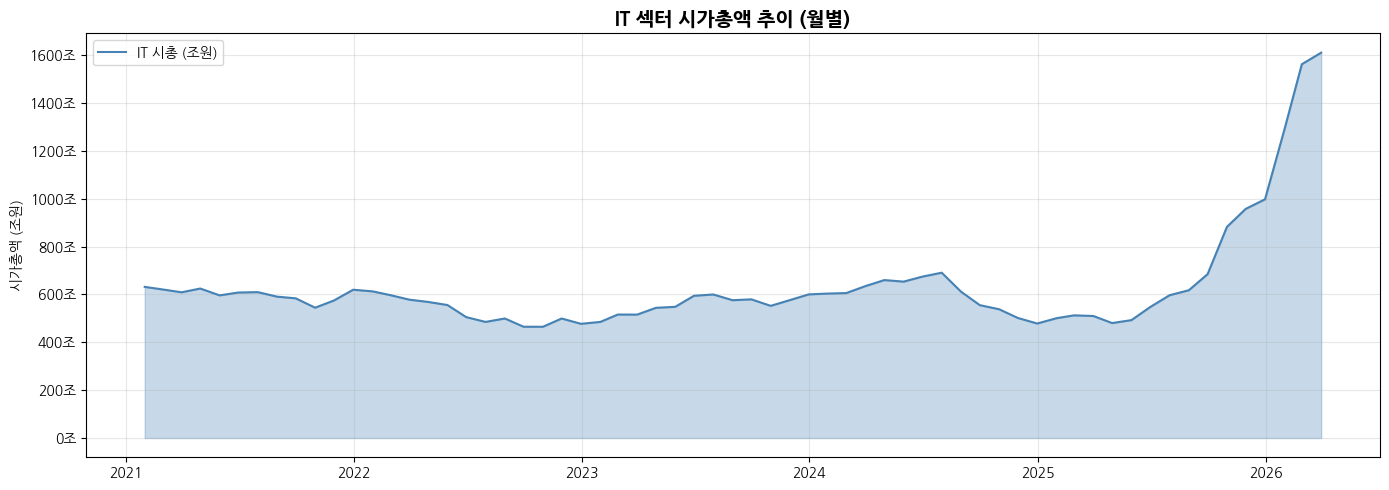

In [4]:
# IT 섹터 전체 시가총액 = IDX_CD별 ALL_MKT_VAL 중복 제거 합산
# IDX_CD가 G45로 시작하는 최상위 집계는 IDX_CD='G45**' 각 소분류별 합을 사용
# ALL_MKT_VAL은 해당 IDX_CD 전체 시총 → 날짜별 소분류별 1행만 취해 합산
it_cap = (
    df_wics
    .groupby(['DATE', 'IDX_CD'])['ALL_MKT_VAL']
    .first()           # 날짜 × 소분류 기준 중복 제거
    .groupby('DATE')   # 날짜별 소분류 합산
    .sum()
    .rename('IT_ALL_MKT_VAL')
)

# 월별 리샘플 (평균)
it_cap_m = it_cap.resample('ME').mean() / 1e6   # 단위: 조원

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(it_cap_m.index, it_cap_m.values, alpha=0.3, color='steelblue')
ax.plot(it_cap_m.index, it_cap_m.values, color='steelblue', linewidth=1.5, label='IT 시총 (조원)')
ax.set_title('IT 섹터 시가총액 추이 (월별)', fontsize=14, fontweight='bold')
ax.set_ylabel('시가총액 (조원)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}조'))
ax.legend()
plt.tight_layout()
plt.show()

### 4. IT 소분류별 시가총액 비중 (최신 날짜 기준)

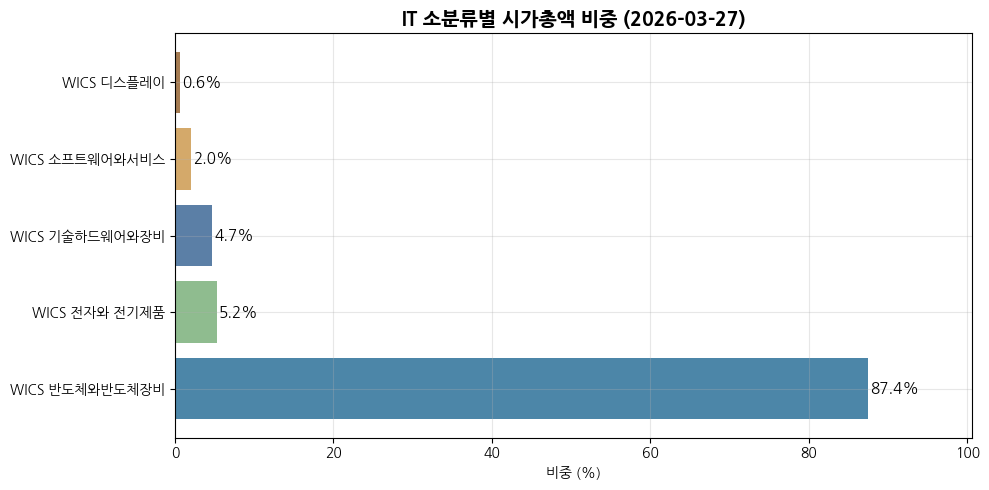

IDX_CD     IDX_NM_KOR  ALL_MKT_VAL     비중(%)
 G4530 WICS 반도체와반도체장비   1364161126 87.441064
 G4535  WICS 전자와 전기제품     81783199  5.242203
 G4520 WICS 기술하드웨어와장비     72926607  4.674507
 G4510 WICS 소프트웨어와서비스     31278415  2.004908
 G4540     WICS 디스플레이      9942741  0.637318


In [5]:
latest_date = df_wics['DATE'].max()
latest = df_wics[df_wics['DATE'] == latest_date]

sub_cap = (
    latest
    .groupby(['IDX_CD', 'IDX_NM_KOR'])['ALL_MKT_VAL']
    .first()
    .reset_index()
    .sort_values('ALL_MKT_VAL', ascending=False)
)
sub_cap['비중(%)'] = sub_cap['ALL_MKT_VAL'] / sub_cap['ALL_MKT_VAL'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C86A8', '#8FBC8F', '#5B7FA6', '#D4A96A', '#A67C52']
bars = ax.barh(sub_cap['IDX_NM_KOR'], sub_cap['비중(%)'], color=colors)
for bar, pct in zip(bars, sub_cap['비중(%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11)
ax.set_title(f'IT 소분류별 시가총액 비중 ({latest_date.date()})', fontsize=14, fontweight='bold')
ax.set_xlabel('비중 (%)')
ax.set_xlim(0, sub_cap['비중(%)'].max() * 1.15)
plt.tight_layout()
plt.show()
print(sub_cap[['IDX_CD','IDX_NM_KOR','ALL_MKT_VAL','비중(%)']].to_string(index=False))

### 5. IT 시총 vs 글로벌 자산 상관관계 분석

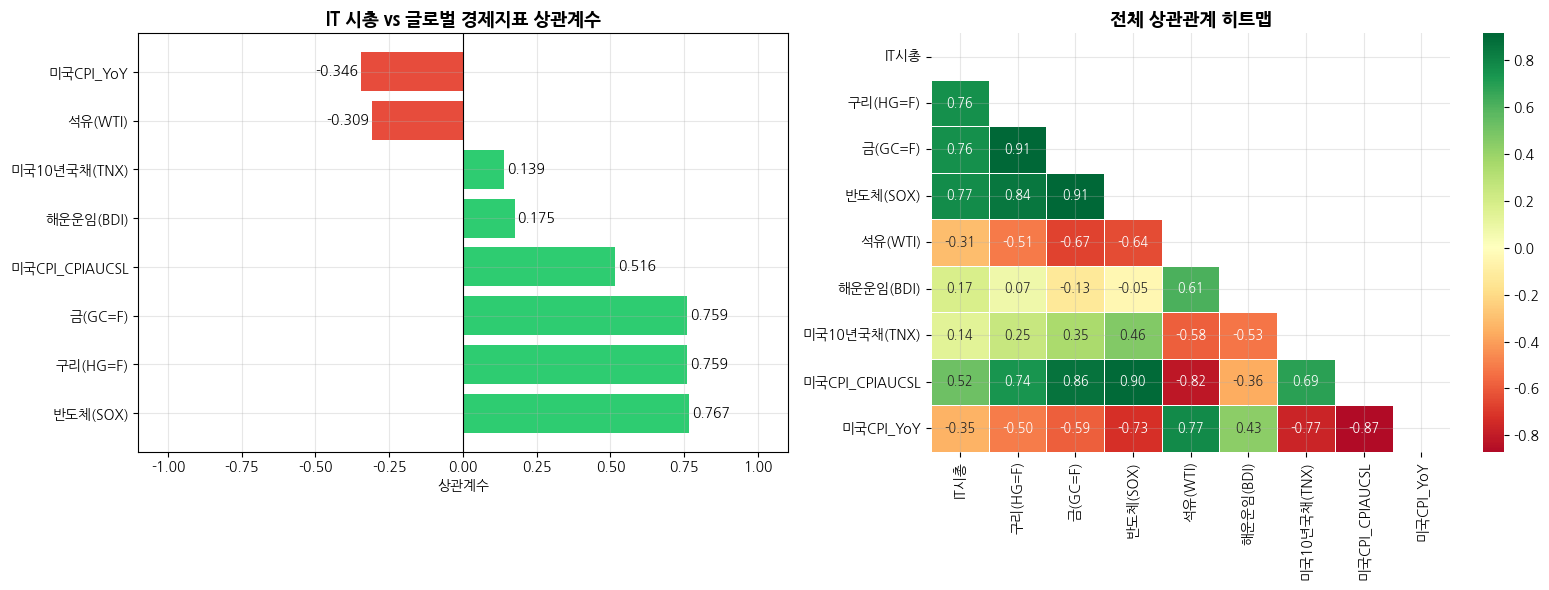


IT 시총과 글로벌 지표 상관계수:
반도체(SOX)          0.766604
구리(HG=F)          0.758784
금(GC=F)           0.758530
미국CPI_CPIAUCSL    0.516243
해운운임(BDI)         0.174986
미국10년국채(TNX)      0.139046
석유(WTI)          -0.309466
미국CPI_YoY        -0.346426


In [6]:
import seaborn as sns

# IT 시총 월별 데이터와 글로벌 자산 월별 데이터 병합
# 글로벌 자산: 영업일 기준 → 월 말 리샘플
asset_m = df_asset.resample('ME').last().dropna(how='all')
it_cap_m2 = it_cap.resample('ME').mean().rename('IT시총')

merged = pd.concat([it_cap_m2, asset_m], axis=1).dropna()

# 상관계수 계산 (IT 시총 vs 각 자산)
corr_with_it = merged.corr()['IT시총'].drop('IT시총').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 막대 그래프
ax = axes[0]
colors_c = ['#2ECC71' if v >= 0 else '#E74C3C' for v in corr_with_it.values]
ax.barh(corr_with_it.index, corr_with_it.values, color=colors_c)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('상관계수')
ax.set_title('IT 시총 vs 글로벌 경제지표 상관계수', fontsize=13, fontweight='bold')
for i, (label, val) in enumerate(corr_with_it.items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_xlim(-1.1, 1.1)

# 히트맵
ax2 = axes[1]
corr_matrix = merged.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax2, linewidths=0.5, annot_kws={'size': 9})
ax2.set_title('전체 상관관계 히트맵', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nIT 시총과 글로벌 지표 상관계수:')
print(corr_with_it.to_string())

### 6. IT 시총 vs 주요 지표 산점도

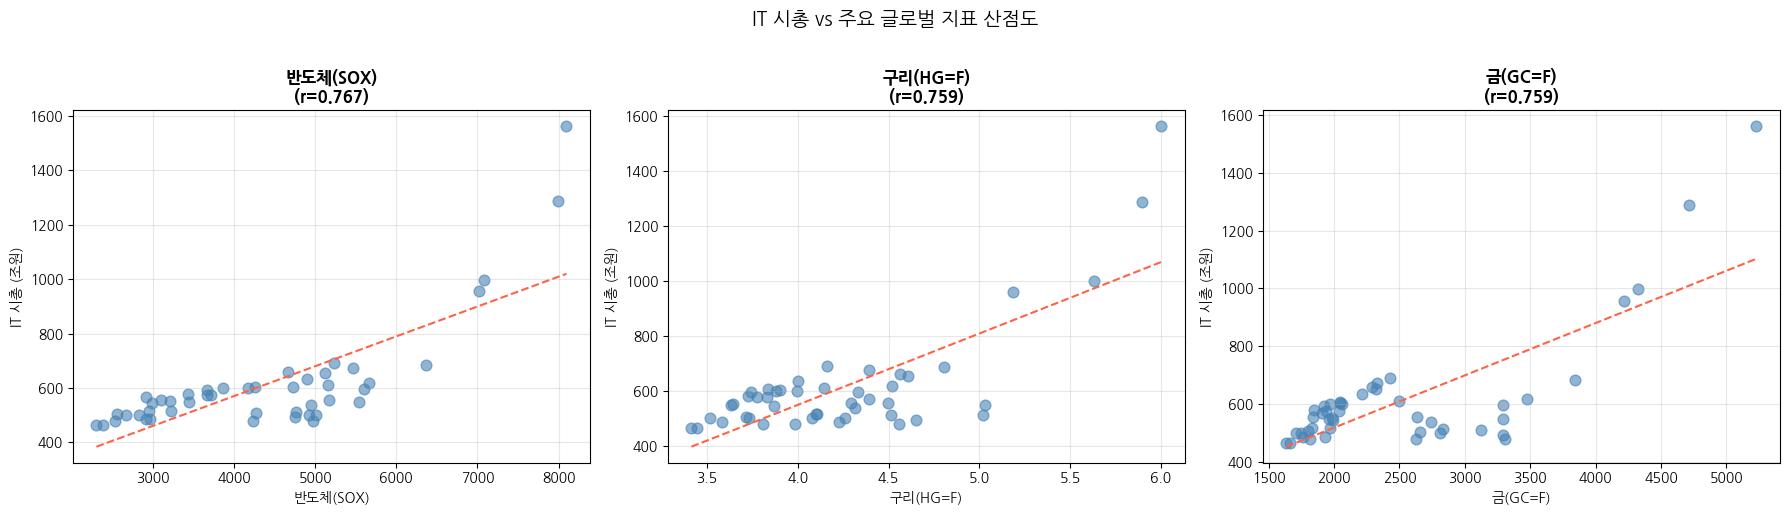

In [7]:
# 상관계수 상위 지표 3개 산점도
top_indicators = corr_with_it.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, top_indicators):
    x = merged[col]
    y = merged['IT시총'] / 1e6  # 조원
    corr_val = np.corrcoef(x.dropna(), y[x.notna()])[0, 1]
    ax.scatter(x, y, alpha=0.6, color='steelblue', s=60)
    # 추세선
    m, b = np.polyfit(x.dropna(), y[x.notna()], 1)
    ax.plot(sorted(x), [m * xi + b for xi in sorted(x)],
            color='tomato', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('IT 시총 (조원)')
    ax.set_title(f'{col}\n(r={corr_val:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('IT 시총 vs 주요 글로벌 지표 산점도', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7. IT 시총 & 반도체(SOX) 추이 비교 (정규화)

In [8]:
df_asset.head()

,구리(HG=F),금(GC=F),반도체(SOX),석유(WTI),해운운임(BDI),미국10년국채(TNX),미국CPI_CPIAUCSL,미국CPI_YoY
Date,,,,,,,,
2021-03-29,4.0430,1712.099976,3054.629883,61.560001,16.870001,NaN,NaN,NaN
2021-03-30,3.9830,1683.900024,3044.550049,60.549999,16.500000,1.726,NaN,NaN
2021-03-31,4.0030,1713.800049,3124.939941,59.160000,16.920000,1.746,NaN,NaN
2021-04-01,4.0035,1726.500000,3240.169922,61.450001,17.930000,1.679,266.614,NaN
2021-04-05,4.1490,1727.000000,3305.429932,58.650002,18.209999,1.720,NaN,NaN


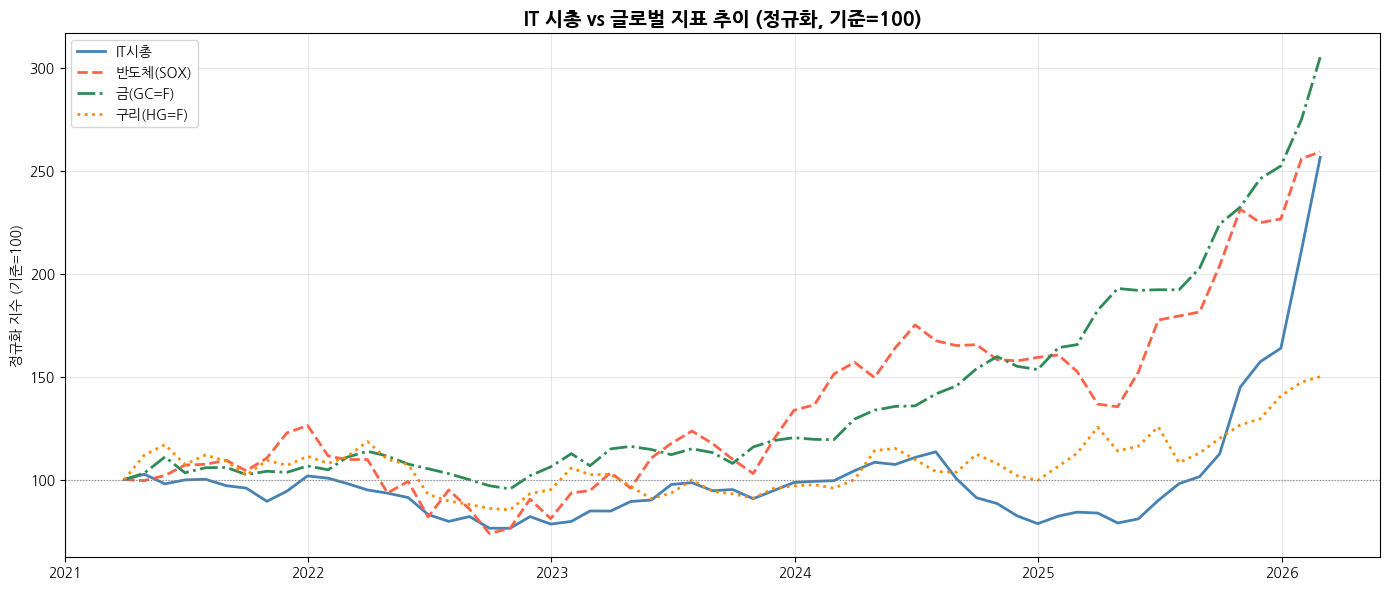

In [9]:
# 정규화 (첫 관측치 = 100)
# IT 시총: 일별 데이터
# SOX: 영업일별 데이터
compare_cols = ['반도체(SOX)', '금(GC=F)', '구리(HG=F)']
available_cols = [c for c in compare_cols if c in df_asset.columns]

# 공통 기간
start = max(df_asset.index[0], it_cap.index[0])
end   = min(df_asset.index[-1], it_cap.index[-1])

# 월별 리샘플 후 정규화
norm_asset = asset_m.loc[start:end, available_cols].copy()
norm_it    = it_cap_m2.loc[start:end].copy().rename('IT시총')

combined = pd.concat([norm_it, norm_asset], axis=1).dropna()
normed = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
line_styles = ['-', '--', '-.', ':']
colors_t = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for i, col in enumerate(normed.columns):
    ax.plot(normed.index, normed[col],
            label=col, linewidth=2,
            linestyle=line_styles[i % len(line_styles)],
            color=colors_t[i % len(colors_t)])

ax.axhline(100, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('IT 시총 vs 글로벌 지표 추이 (정규화, 기준=100)', fontsize=14, fontweight='bold')
ax.set_ylabel('정규화 지수 (기준=100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 8. 분석 결과 CSV 저장

In [10]:
# IT 시총 월별 시계열 저장
it_cap_save = it_cap_m2.to_frame().reset_index()
it_cap_save.columns = ['Date', 'IT_TotalMarketCap']
it_cap_save_path = os.path.join(OUT_DIR, 'it_market_cap_monthly.csv')
it_cap_save.to_csv(it_cap_save_path, index=False, encoding='utf-8-sig')
print(f'✅ IT 시총 월별: {it_cap_save_path}')

# 상관계수 저장
corr_save = corr_with_it.reset_index()
corr_save.columns = ['지표', 'IT시총_상관계수']
corr_save_path = os.path.join(OUT_DIR, 'it_correlation_result.csv')
corr_save.to_csv(corr_save_path, index=False, encoding='utf-8-sig')
print(f'✅ 상관계수 결과: {corr_save_path}')

# 소분류 시가총액 저장
sub_save_path = os.path.join(OUT_DIR, 'it_subsector_cap.csv')
sub_cap.to_csv(sub_save_path, index=False, encoding='utf-8-sig')
print(f'✅ 소분류 시가총액: {sub_save_path}')

print('\n=== 저장 완료 ===')
print(f'  - {it_cap_save_path}')
print(f'  - {corr_save_path}')
print(f'  - {sub_save_path}')
print(f'  - {os.path.join(OUT_DIR, "it_market_cap.png")}')
print(f'  - {os.path.join(OUT_DIR, "it_subsector_weight.png")}')
print(f'  - {os.path.join(OUT_DIR, "it_correlation.png")}')
print(f'  - {os.path.join(OUT_DIR, "it_scatter.png")}')
print(f'  - {os.path.join(OUT_DIR, "it_trend_normalized.png")}')

✅ IT 시총 월별: data\analysis/it\it_market_cap_monthly.csv
✅ 상관계수 결과: data\analysis/it\it_correlation_result.csv
✅ 소분류 시가총액: data\analysis/it\it_subsector_cap.csv

=== 저장 완료 ===
  - data\analysis/it\it_market_cap_monthly.csv
  - data\analysis/it\it_correlation_result.csv
  - data\analysis/it\it_subsector_cap.csv
  - data\analysis/it\it_market_cap.png
  - data\analysis/it\it_subsector_weight.png
  - data\analysis/it\it_correlation.png
  - data\analysis/it\it_scatter.png
  - data\analysis/it\it_trend_normalized.png
